## Import packages required for processing and analysis 

In [524]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# text preprocessing modules
import nltk
nltk.download('punkt_tab') 
import re
from nltk.corpus import stopwords 
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
# text-tagging modules and text-tagging visiuals
import spacy
from spacy import displacy
from spacy import tokenizer
from IPython.display import HTML, display
# text sentiment modules
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
# text vectorizing modules
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
# topic modeling modelus
import gensim
import gensim.corpora as corpora
from gensim.models.coherencemodel import CoherenceModel
from gensim.models import LsiModel, TfidfModel
# text classification modelus  
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import accuracy_score, classification_report

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\richm\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [525]:
plt.rcParams["figure.figsize"] = (12, 8)
default_plot_color = "#00bfbf"

In [526]:
data = pd.read_csv(r"data\fake_news_data.csv")
data.head()

,title,text,date,fake_or_factual
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News


In [527]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 198 entries, 0 to 197
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   title            198 non-null    str  
 1   text             198 non-null    str  
 2   date             198 non-null    str  
 3   fake_or_factual  198 non-null    str  
dtypes: str(4)
memory usage: 6.3 KB


Text(0.5, 1.0, 'Count Article Classiication')

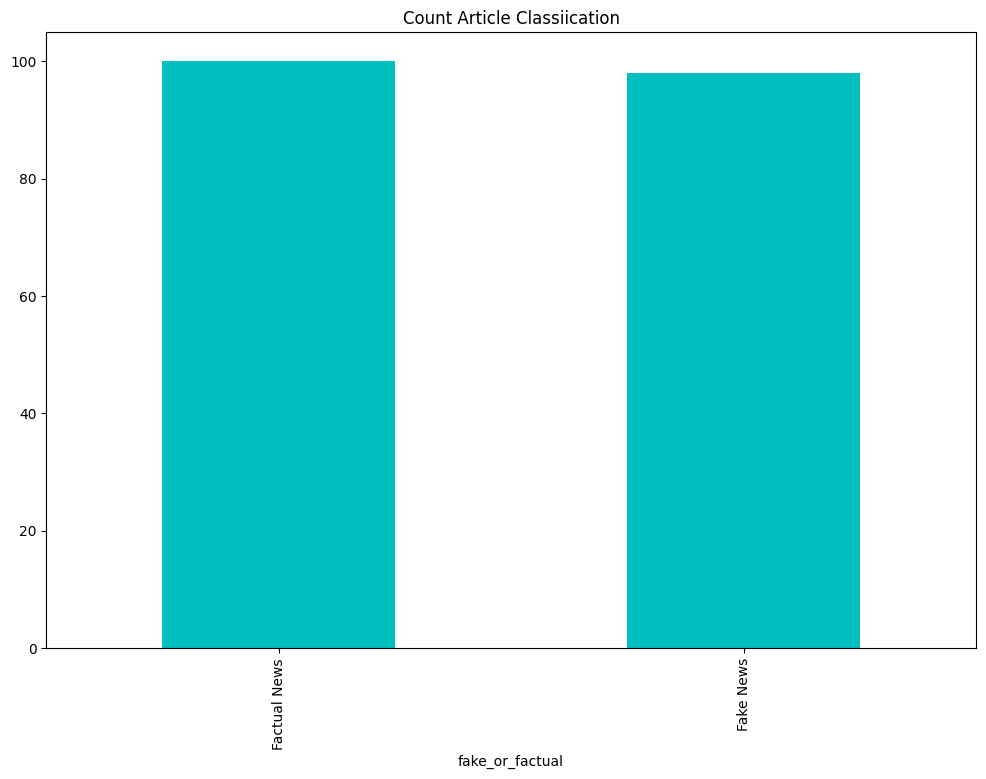

In [528]:
data["fake_or_factual"].value_counts().plot(kind="bar", color=default_plot_color)
plt.title("Count Article Classiication")

In [529]:
data["fake_or_factual"][data["fake_or_factual"] == "Factual News"].value_counts()

fake_or_factual
Factual News    100
Name: count, dtype: int64

## POS Tagging

In [530]:
nlp = spacy.load("en_core_web_sm")

In [531]:
fact_news = data[data["fake_or_factual"] == "Factual News"]
fake_news = data[data["fake_or_factual"] == "Fake News"]


In [532]:
fake_spacy_doc= list(nlp.pipe(fake_news["text"]))
fact_spacy_doc = list(nlp.pipe(fact_news["text"]))

In [533]:
fact_spacy_doc

[WASHINGTON (Reuters) - U.S. Defense Secretary Jim Mattis said on Monday that Russia s bombing of U.S-backed fighters in Syria was being discussed at the highest levels and while a communication link between the two countries had worked to avoid such incidents, the strike over the weekend was a departure.  When you look at the fact that this is a change, you can imagine this is at the highest levels,  Mattis told reporters. Russia s Defense Ministry on Sunday rejected the allegations, saying its planes only targeted Islamic State militants and that it had warned the United States well in advance of its operational plans. ,
 BELFAST (Reuters) - Northern Ireland s political parties are rapidly running out of time to restore a devolved power-sharing government, Britain s minister for the region said on Monday, as he sought to avoid a return of direct rule from London.  The window of opportunity to restore devolution and to form an executive is closing rapidly as we move further into the a

In [534]:
def extract_token_tags(doc: spacy.tokens.doc.Doc):
    return [(token.text, token.pos_, token.ent_type_) for token in doc]

In [535]:
fake_tags_df = []
columns = ["token","pos_tag","ner_tag"]

In [536]:
for _, doc in enumerate(fake_spacy_doc):
    tags = extract_token_tags(doc)
    tags = pd.DataFrame(tags)    
    tags.columns = columns
    fake_tags_df.append(tags)

In [537]:
fake_tags_df[0].head()

,token,pos_tag,ner_tag
0,There,PRON,
1,are,VERB,
2,two,NUM,CARDINAL
3,small,ADJ,
4,problems,NOUN,


In [538]:
fake_tags_df = pd.concat(fake_tags_df)

In [539]:
fact_tags_df = []

for _ , doc in enumerate(fact_spacy_doc):
    tags = extract_token_tags(doc)
    tags_df = pd.DataFrame(tags)
    tags_df.columns = columns
    fact_tags_df.append(tags_df)

In [540]:
fact_tags_df = pd.concat(fact_tags_df)

In [541]:
fake_tags_df.head()

,token,pos_tag,ner_tag
0,There,PRON,
1,are,VERB,
2,two,NUM,CARDINAL
3,small,ADJ,
4,problems,NOUN,


In [542]:
fact_tags_df.head()

,token,pos_tag,ner_tag
0,WASHINGTON,PROPN,GPE
1,(,PUNCT,
2,Reuters,PROPN,ORG
3,),PUNCT,
4,-,PUNCT,


In [543]:
# token frequency count
pos_counts_fake = fake_tags_df.groupby(["token", "pos_tag"]).size().reset_index(name="pos_count").sort_values(by="pos_count", ascending=False)
pos_counts_fake

,token,pos_tag,pos_count
29,",",PUNCT,1908
7451,the,DET,1834
41,.,PUNCT,1530
5766,of,ADP,922
2665,and,CCONJ,875
...,...,...,...
3008,boats,NOUN,1
24,*,PROPN,1
23,*,AUX,1
3006,boasted,VERB,1


In [544]:
pos_counts_fact = fact_tags_df.groupby(["token", "pos_tag"]).size().reset_index(name="pos_count").sort_values(by="pos_count", ascending=False)
pos_counts_fact

,token,pos_tag,pos_count
6145,the,DET,1903
14,",",PUNCT,1698
21,.,PUNCT,1382
4716,of,ADP,884
1898,a,DET,789
...,...,...,...
3209,drilled,VERB,1
3212,drilling,VERB,1
6644,’s,CCONJ,1
43,10th,ADJ,1


In [545]:
# frequent pos of fake news
pos_counts_fake.groupby(["pos_tag"])["token"].count().sort_values(ascending=False)

pos_tag
NOUN     2586
VERB     1817
PROPN    1672
ADJ       882
ADV       413
NUM       221
PRON       96
ADP        89
AUX        62
SCONJ      51
DET        42
INTJ       24
PUNCT      23
CCONJ      19
X          14
PART       10
SYM         5
SPACE       3
Name: token, dtype: int64

#### frequency count

In [546]:
# frequent pos of factual news
pos_counts_fact.groupby(["pos_tag"])["token"].count().sort_values(ascending=False)

pos_tag
NOUN     2179
VERB     1539
PROPN    1379
ADJ       747
ADV       263
NUM       205
PRON       79
ADP        70
AUX        43
SCONJ      42
DET        36
PUNCT      22
CCONJ      11
SPACE      11
X          10
INTJ        7
PART        7
SYM         4
Name: token, dtype: int64

In [547]:
pos_counts_fact[pos_counts_fact.pos_tag == "NOUN"][:10]

,token,pos_tag,pos_count
3738,government,NOUN,71
6618,year,NOUN,64
5901,state,NOUN,57
2360,bill,NOUN,55
1975,administration,NOUN,51
5066,president,NOUN,49
3277,election,NOUN,48
4919,people,NOUN,45
4786,order,NOUN,45
2497,campaign,NOUN,42


In [548]:
pos_counts_fake[pos_counts_fake.pos_tag == "NOUN"][:10]

,token,pos_tag,pos_count
5981,people,NOUN,77
7349,t,NOUN,65
6216,president,NOUN,58
7960,women,NOUN,55
7516,time,NOUN,52
8011,year,NOUN,44
3138,campaign,NOUN,44
4581,government,NOUN,41
5213,law,NOUN,40
8013,years,NOUN,40


## Named Entities

In [549]:
top_entities_fake = fake_tags_df[fake_tags_df["ner_tag"] != ""].groupby(["token", "ner_tag"]).size().reset_index(name="ner_count").sort_values(by="ner_count",ascending=False)

In [550]:
top_entities_fact = fact_tags_df[fact_tags_df["ner_tag"] != ""].groupby(["token", "ner_tag"]).size().reset_index(name="ner_count").sort_values(by="ner_count",ascending=False)

In [551]:
top_entities_fake.head(10)

,token,ner_tag,ner_count
1730,Trump,PERSON,154
1729,Trump,ORG,152
2129,the,ORG,121
592,Clinton,PERSON,118
718,Donald,PERSON,75
890,Hillary,PERSON,64
1329,Obama,PERSON,59
1179,McCain,PERSON,53
2167,year,DATE,44
1662,Syria,GPE,42


In [552]:
top_entities_fact.head(10)

,token,ner_tag,ner_count
1968,the,ORG,159
1633,U.S.,GPE,138
1373,Reuters,ORG,131
1615,Trump,PERSON,125
1614,Trump,ORG,124
882,House,ORG,67
1997,year,DATE,63
1965,the,GPE,59
1646,United,GPE,59
1532,States,GPE,55


#### frequency count

In [553]:
top_entities_fact.groupby(["ner_tag"])["token"].count().sort_values(ascending=False)

ner_tag
PERSON         545
ORG            524
GPE            232
DATE           220
CARDINAL       106
NORP            85
MONEY           47
LOC             45
PERCENT         39
QUANTITY        38
TIME            30
LAW             30
FAC             24
EVENT           15
PRODUCT         13
ORDINAL          9
WORK_OF_ART      3
LANGUAGE         2
Name: token, dtype: int64

In [554]:
top_entities_fake.groupby(["ner_tag"])["token"].count().sort_values(ascending=False)

ner_tag
ORG            639
PERSON         617
DATE           238
GPE            184
CARDINAL       121
NORP            71
MONEY           59
TIME            44
FAC             36
PERCENT         31
WORK_OF_ART     29
LOC             27
LAW             24
EVENT           14
PRODUCT         13
QUANTITY        12
ORDINAL         11
Name: token, dtype: int64

In [555]:
# custom color palette
# create custom palette to ensure plots are consistent
ner_palette = {
    'ORG': sns.color_palette("Set2").as_hex()[0],
    'GPE': sns.color_palette("Set2").as_hex()[1],
    'NORP': sns.color_palette("Set2").as_hex()[2],
    'PERSON': sns.color_palette("Set2").as_hex()[3],
    'DATE': sns.color_palette("Set2").as_hex()[4],
    'CARDINAL': sns.color_palette("Set2").as_hex()[5],
    'PERCENT': sns.color_palette("Set2").as_hex()[6]
}

[Text(0.5, 1.0, 'Most Common Entities in Fake News')]

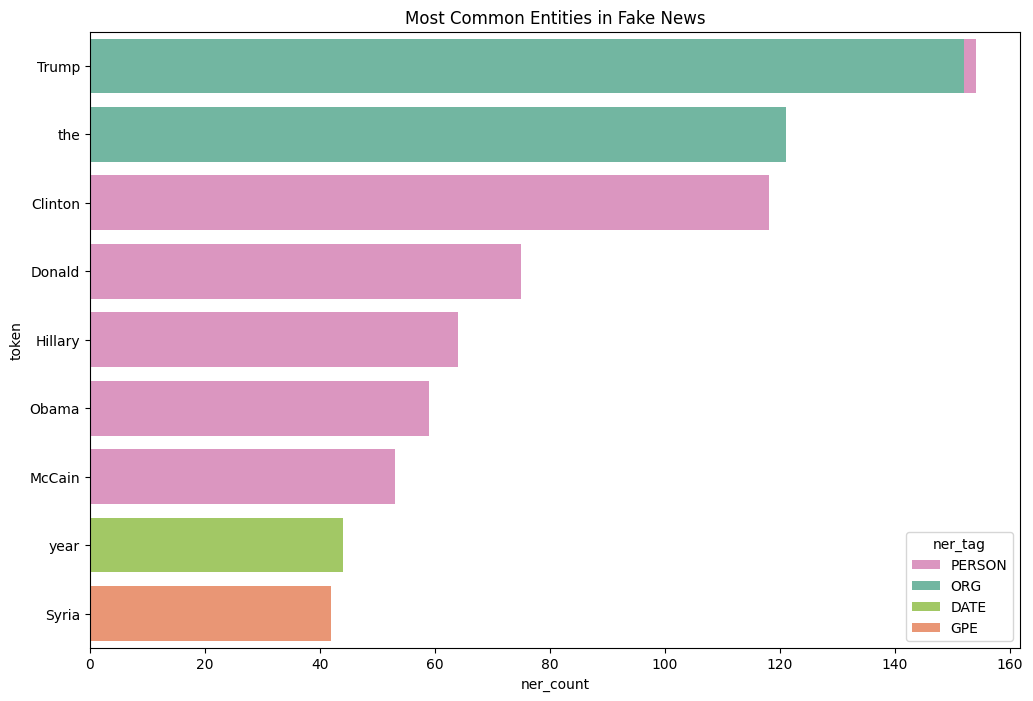

In [556]:
sns.barplot(
    x = "ner_count",
    y="token",
    hue="ner_tag",
    palette=ner_palette,
    data = top_entities_fake[:10],
    dodge=False
).set(title="Most Common Entities in Fake News")

[Text(0.5, 1.0, 'Most Common Entities in Factual News')]

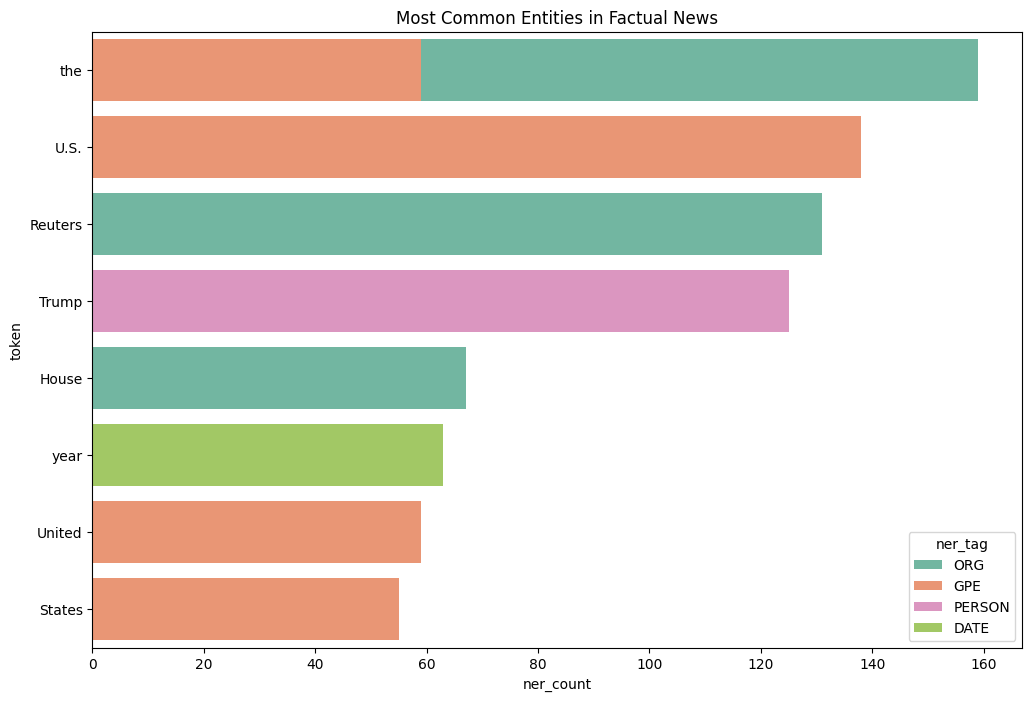

In [557]:
sns.barplot(
    x = "ner_count",
    y="token",
    hue="ner_tag",
    palette=ner_palette,
    data = top_entities_fact[:10],
    dodge=False
).set(title="Most Common Entities in Factual News")

## Text Pre-processing

In [558]:
data.head(10)

,title,text,date,fake_or_factual
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News
5,Maxine Waters Makes Teens Chant ‘Impeach 45′ a...,Shame on Teen Vogue! Maxine Waters was a guest...,"Dec 10, 2017",Fake News
6,Jay Carney Let It Slip That He Knows Who Obam...,Former White House Press Secretary in the Obam...,"February 10, 2016",Fake News
7,"Trump threat fires up U.S. climate activists, ...",(Reuters) - Seattle financial worker Harrison ...,"November 11, 2016",Factual News
8,Stephen King Is BRUTALLY Making Fun Of Trump ...,With Donald Trump s intensely bizarre and craz...,"March 4, 2017",Fake News
9,China labels Trump call 'petty action' by Taiw...,BEIJING (Reuters) - U.S. President-elect Donal...,"December 3, 2016",Factual News


In [559]:
# remove hyphen
data["text_clean"] = data["text"].apply(lambda news: re.sub(r"^[^-]*-\s*", "", news))

In [560]:
data["text_clean"].head(10)

0    year-old Oscar-winning actress described meeti...
1    Buried in Trump s bonkers interview with New Y...
2    Women make up over 50 percent of this country,...
3    U.S. Defense Secretary Jim Mattis said on Mond...
4    Northern Ireland s political parties are rapid...
5    58 against a resolution to consider the move t...
6    in-neck race. He must be pretty antsy, though,...
7    Seattle financial worker Harrison Karlewicz ha...
8    With Donald Trump s intensely bizarre and craz...
9    U.S. President-elect Donald Trump’s call with ...
Name: text_clean, dtype: str

In [561]:
# text to lowercase
data["text_clean"] = data["text_clean"].str.lower()

In [562]:
data["text_clean"].head(10)

0    year-old oscar-winning actress described meeti...
1    buried in trump s bonkers interview with new y...
2    women make up over 50 percent of this country,...
3    u.s. defense secretary jim mattis said on mond...
4    northern ireland s political parties are rapid...
5    58 against a resolution to consider the move t...
6    in-neck race. he must be pretty antsy, though,...
7    seattle financial worker harrison karlewicz ha...
8    with donald trump s intensely bizarre and craz...
9    u.s. president-elect donald trump’s call with ...
Name: text_clean, dtype: str

In [563]:
# remove all punctuations 
data["text_clean"] = data["text_clean"].apply(lambda news: re.sub(r"[^\w\s]", "", news))

In [564]:
data["text_clean"].head(10)

0    yearold oscarwinning actress described meeting...
1    buried in trump s bonkers interview with new y...
2    women make up over 50 percent of this country ...
3    us defense secretary jim mattis said on monday...
4    northern ireland s political parties are rapid...
5    58 against a resolution to consider the move t...
6    inneck race he must be pretty antsy though bei...
7    seattle financial worker harrison karlewicz ha...
8    with donald trump s intensely bizarre and craz...
9    us presidentelect donald trumps call with taiw...
Name: text_clean, dtype: str

In [565]:
# remove stopwords
en_stopwords = stopwords.words("english")
data["text_clean"] = data["text_clean"].apply(lambda text: " ".join([word for word in text.split() if word not in en_stopwords]))

In [566]:
data["text_clean"].head(10)

0    yearold oscarwinning actress described meeting...
1    buried trump bonkers interview new york times ...
2    women make 50 percent country grossly underrep...
3    us defense secretary jim mattis said monday ru...
4    northern ireland political parties rapidly run...
5    58 resolution consider move week fox news repo...
6    inneck race must pretty antsy though unable en...
7    seattle financial worker harrison karlewicz co...
8    donald trump intensely bizarre crazy tweetstor...
9    us presidentelect donald trumps call taiwan pr...
Name: text_clean, dtype: str

In [567]:
# tokenize text
data["text_clean"] = data["text_clean"].apply(lambda text: word_tokenize(text))

In [568]:
data["text_clean"].head(10)

0    [yearold, oscarwinning, actress, described, me...
1    [buried, trump, bonkers, interview, new, york,...
2    [women, make, 50, percent, country, grossly, u...
3    [us, defense, secretary, jim, mattis, said, mo...
4    [northern, ireland, political, parties, rapidl...
5    [58, resolution, consider, move, week, fox, ne...
6    [inneck, race, must, pretty, antsy, though, un...
7    [seattle, financial, worker, harrison, karlewi...
8    [donald, trump, intensely, bizarre, crazy, twe...
9    [us, presidentelect, donald, trumps, call, tai...
Name: text_clean, dtype: object

In [569]:
# lemmetize tokens
lem = WordNetLemmatizer()
data["text_clean"] = data["text_clean"].apply(lambda lst: [lem.lemmatize(word) for word in lst])

In [570]:
data["text_clean"].head(10)

0    [yearold, oscarwinning, actress, described, me...
1    [buried, trump, bonkers, interview, new, york,...
2    [woman, make, 50, percent, country, grossly, u...
3    [u, defense, secretary, jim, mattis, said, mon...
4    [northern, ireland, political, party, rapidly,...
5    [58, resolution, consider, move, week, fox, ne...
6    [inneck, race, must, pretty, antsy, though, un...
7    [seattle, financial, worker, harrison, karlewi...
8    [donald, trump, intensely, bizarre, crazy, twe...
9    [u, presidentelect, donald, trump, call, taiwa...
Name: text_clean, dtype: object

In [ ]:
# common unigrams after preprocessing
tokens = sum(data["text_clean"], [])
unigram = (pd.Series(nltk.ngrams(tokens, 1)).value_counts())
unigram[:10]

(said,)          560
(trump,)         520
(u,)             255
(state,)         250
(president,)     226
(would,)         210
(one,)           141
(year,)          128
(republican,)    128
(also,)          124
Name: count, dtype: int64

In [572]:
unigram_df = unigram.reset_index()
unigram_df.columns = ["token", "count"]
unigram_df["token"] = unigram_df["token"].apply(lambda tuple: tuple[0])
unigram_df.head(5)

,token,count
0,said,560
1,trump,520
2,u,255
3,state,250
4,president,226


[Text(0.5, 1.0, 'Most Occuring Token in Document')]

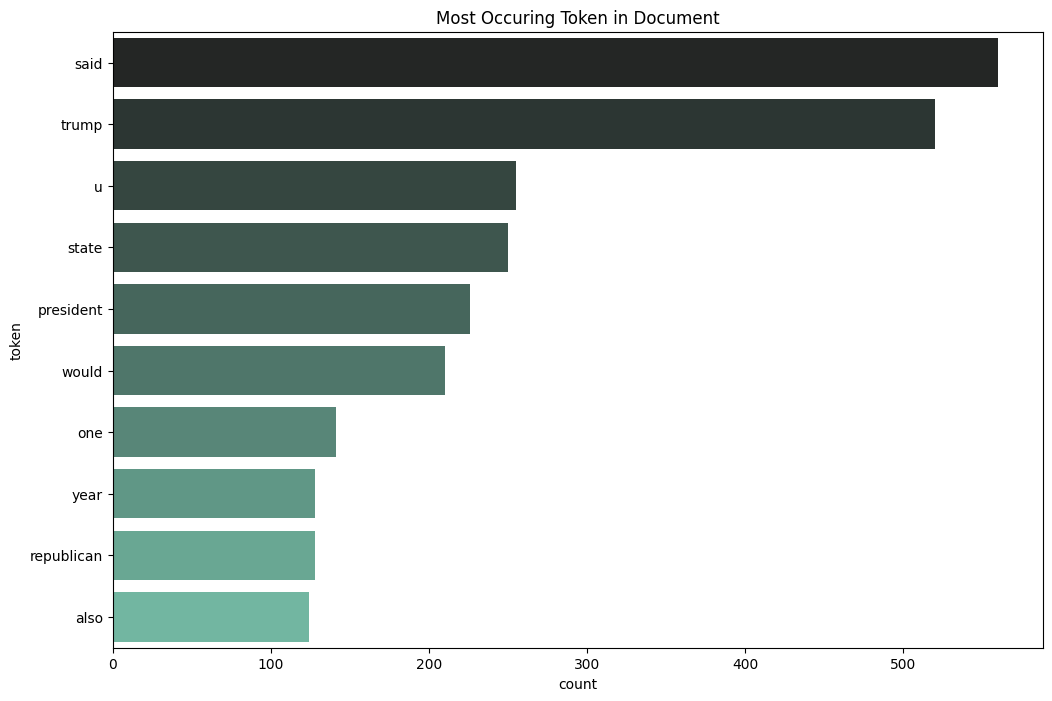

In [576]:
# visizualise words that appear the most
sns.barplot(
    x = "count",
    y = "token",
    palette='dark:#66c2a5',
    data= unigram_df[:10],
    dodge=False,
    hue="token"
).set(title = "Most Occuring Token in Document")

In [577]:
#  common bigrams after preprocessing
unigram = (pd.Series(nltk.ngrams(tokens, 2)).value_counts())
unigram[:10]

(donald, trump)            92
(united, state)            80
(white, house)             72
(president, donald)        42
(new, york)                31
(hillary, clinton)         31
(image, via)               29
(supreme, court)           29
(official, said)           26
(trump, administration)    24
Name: count, dtype: int64

## Sentiment Analysis

## LDA

## TF-IDF & LSA

## Predict fake or factual news